In [1]:
import math
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import torchaudio.transforms as T
from pathlib import Path
import os
import pandas as pd

# read in the dataset
FSD50K = Path('./data')
audio = FSD50K /'FSD50K.dev_audio'

# Audio Setup for TorchAudio
CLIP_TIME    = 5.94   # Seconds 
SAMPLE_RATE  = 22050  # Half of native
SAMPLE_COUNT = int(SAMPLE_RATE * CLIP_TIME)
HOP_LENGTH   = 256    # Step between windows
MEL_N        = 128    # Mel filter banks
FFT_N        = 1024   # FFT window
F_MIN        = 100    # Hz
F_MAX        = 10000  # Hz
DB_MAX       = 80.0   # DB

# Expected time frames for a 5-second clip
FRAME_COUNT = math.ceil(SAMPLE_COUNT / HOP_LENGTH)
print(f"Target shape per clip: (1, {MEL_N}, {FRAME_COUNT})")

Target shape per clip: (1, 128, 512)


In [2]:
# Pick the first wav file in the dev audio folder
wav_files = sorted(audio.glob("*.wav"))
test_file = wav_files[0]
waveform, sr = torchaudio.load(test_file)

print(f"File        : {test_file.name}")
print(f"Sample rate : {sr} Hz")
print(f"Channels    : {waveform.shape[0]}")
print(f"Samples     : {waveform.shape[1]}")
print(f"Duration    : {waveform.shape[1] / sr:.2f} s")

File        : 10000.wav
Sample rate : 44100 Hz
Channels    : 1
Samples     : 18856
Duration    : 0.43 s


In [3]:
"""#find the median length of all the audio files in the dataset
lengths = []
for wav_file in wav_files:
    waveform, sr = torchaudio.load(wav_file)
    lengths.append(waveform.shape[1])
median_length = np.mean(lengths)
print(f"Median length of audio files: {median_length / sr:.2f} seconds"
#median length is 4.5 seconds
#mean length is 7.18 seconds
"""

'#find the median length of all the audio files in the dataset\nlengths = []\nfor wav_file in wav_files:\n    waveform, sr = torchaudio.load(wav_file)\n    lengths.append(waveform.shape[1])\nmedian_length = np.mean(lengths)\nprint(f"Median length of audio files: {median_length / sr:.2f} seconds"\n#median length is 4.5 seconds\n#mean length is 7.18 seconds\n'

### Compute Log-Mel SPectrogram

In [4]:
NORM_MEAN = -22.69  # dB
NORM_STD = 21.58    # dB

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=FFT_N,
    hop_length=HOP_LENGTH,
    n_mels=MEL_N,
    f_min=F_MIN,
    f_max=F_MAX,
    power=2.0
)
to_db = T.AmplitudeToDB(stype='power', top_db=DB_MAX)

def audio_to_log_mel(path: Path, norm_mean: float = NORM_MEAN, norm_std: float = NORM_STD) -> torch.Tensor:
    waveform, sr = torchaudio.load(path)
    waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    waveform = waveform.mean(dim=0, keepdim=True)  # Convert to mono

    waveform = waveform.repeat(1, math.ceil(SAMPLE_COUNT / waveform.shape[1]))
    midpoint = (waveform.shape[1] - SAMPLE_COUNT) // 2
    waveform = waveform[:, midpoint : midpoint + SAMPLE_COUNT]

    log_mel = to_db(mel_transform(waveform))

    # fic time axis 
    if log_mel.shape[-1] < FRAME_COUNT: log_mel = torch.nn.functional.pad(log_mel, (0, FRAME_COUNT - log_mel.shape[-1]))
    else : log_mel = log_mel[:, :, :FRAME_COUNT]

    # Normalize
    return (log_mel - norm_mean) / (norm_std + 1e-6)

#quick test 
spec = audio_to_log_mel(test_file)
print(f"Log-Mel Spectrogram shape: {spec.shape}")
print(f"Value range: {spec.min():.2f} to {spec.max():.2f}")
print(f'dtype: {spec.dtype}')



Log-Mel Spectrogram shape: torch.Size([1, 128, 512])
Value range: -1.16 to 1.64
dtype: torch.float32


### Make dataframe

In [5]:
df                      = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'dev.csv')
df_train                = df[df['split'] == 'train'].reset_index(drop=True)
df_train['labels']   = df_train['labels'].apply(lambda x: x.split(','))
df_train['audio_path']  = df_train['fname'].apply(lambda x: os.path.join(audio, f'{x}.wav'))
print(df_train['audio_path'])

df_eval = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'eval.csv')
df_eval['labels']     = df_eval['labels'].apply(lambda x: x.split(','))
df_eval['audio_path'] = df_eval['fname'].apply(lambda x: os.path.join(FSD50K / 'FSD50K.eval_audio', f'{x}.wav'))

0         data\FSD50K.dev_audio\64760.wav
1         data\FSD50K.dev_audio\16399.wav
2         data\FSD50K.dev_audio\16401.wav
3         data\FSD50K.dev_audio\16402.wav
4         data\FSD50K.dev_audio\16404.wav
                       ...               
36791    data\FSD50K.dev_audio\102863.wav
36792    data\FSD50K.dev_audio\389607.wav
36793     data\FSD50K.dev_audio\90091.wav
36794    data\FSD50K.dev_audio\244718.wav
36795     data\FSD50K.dev_audio\24061.wav
Name: audio_path, Length: 36796, dtype: object


In [6]:
vocabulary = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'vocabulary.csv')
vocabulary.columns = ["index", "label", "mid"]
vocabulary             = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'vocabulary.csv')
vocabulary.columns     = ["index", "label", "mid"]
label_to_idx           = {label: idx for idx, label in enumerate(vocabulary['label'].unique())}
num_classes            = len(label_to_idx)

print(f"Train clips: {len(df_train)}")
print(f"Num classes: {num_classes}")

Train clips: 36796
Num classes: 199


### Normalise all spectrograms and save as .pt files


In [7]:
from tqdm import tqdm
"""
# Pass 1: Compute dataset-wide mean and std for normalisation
total_sum, total_sq_sum, total_count = 0.0, 0.0, 0
train_df = df[df['split'] == 'train']
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Computing normalisation stats"):
    path = audio / f"{row['fname']}.wav"
    spec = audio_to_log_mel(path, norm_mean=0.0, norm_std=1.0)
    total_sum    += spec.sum().item()
    total_sq_sum += (spec ** 2).sum().item()
    total_count  += spec.numel()

NORM_MEAN = total_sum / total_count
NORM_STD  = (total_sq_sum / total_count - NORM_MEAN ** 2) ** 0.5
print(f"NORM_MEAN = {NORM_MEAN:.2f}, NORM_STD = {NORM_STD:.2f}")

# Pass 2: Preprocess all files and save as .pt tensors
for split in ['train', 'val']:
    output_dir = Path(f"preprocessed/{split}")
    output_dir.mkdir(parents=True, exist_ok=True)
    split_df = df[df['split'] == split]
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Preprocessing {split}"):
        fname = row['fname']
        spec  = audio_to_log_mel(audio / f"{fname}.wav", NORM_MEAN, NORM_STD)
        torch.save(spec, output_dir / f"{fname}.pt")
"""


'\n# Pass 1: Compute dataset-wide mean and std for normalisation\ntotal_sum, total_sq_sum, total_count = 0.0, 0.0, 0\ntrain_df = df[df[\'split\'] == \'train\']\nfor _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Computing normalisation stats"):\n    path = audio / f"{row[\'fname\']}.wav"\n    spec = audio_to_log_mel(path, norm_mean=0.0, norm_std=1.0)\n    total_sum    += spec.sum().item()\n    total_sq_sum += (spec ** 2).sum().item()\n    total_count  += spec.numel()\n\nNORM_MEAN = total_sum / total_count\nNORM_STD  = (total_sq_sum / total_count - NORM_MEAN ** 2) ** 0.5\nprint(f"NORM_MEAN = {NORM_MEAN:.2f}, NORM_STD = {NORM_STD:.2f}")\n\n# Pass 2: Preprocess all files and save as .pt tensors\nfor split in [\'train\', \'val\']:\n    output_dir = Path(f"preprocessed/{split}")\n    output_dir.mkdir(parents=True, exist_ok=True)\n    split_df = df[df[\'split\'] == split]\n    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Preprocessing {split}"):\n      

In [8]:
# spectral augmentatino (time stretch, pitch shifting and volume pertubation)
import torch.nn.functional as F

def time_stretch(spec, rate_min=0.8, rate_max=1.2):
    """Stretch or compress the time axis by resampling."""
    rate      = np.random.uniform(rate_min, rate_max)
    orig_len  = spec.shape[-1]
    new_len   = int(orig_len / rate)
    # Resize along time axis then crop/pad back to original length
    stretched = F.interpolate(spec.unsqueeze(0), size=(spec.shape[-2], new_len), 
                               mode='bilinear', align_corners=False).squeeze(0)
    if new_len >= orig_len:
        return stretched[:, :, :orig_len]
    else:
        return F.pad(stretched, (0, orig_len - new_len))

def pitch_shift(spec, shift_min=-2, shift_max=2):
    """Shift frequency bins up or down by rolling along frequency axis."""
    shift = np.random.randint(shift_min, shift_max + 1)
    return torch.roll(spec, shifts=shift, dims=-2)

def volume_perturbation(spec, gain_min=-6.0, gain_max=6.0):
    """Multiply spectrogram by a random gain in dB."""
    gain_db = np.random.uniform(gain_min, gain_max)
    gain    = 10 ** (gain_db / 20.0)
    return spec * gain

def augment_spec(spec):
    if np.random.random() > 0.5:
        spec = time_stretch(spec)
    if np.random.random() > 0.5:
        spec = pitch_shift(spec)
    if np.random.random() > 0.5:
        spec = volume_perturbation(spec)
    return spec

### make function for torch dataloader:

In [9]:
# class dataset function
from torch.utils.data import Dataset, DataLoader
import torch

class FSD50KDataset(Dataset):
    def __init__(self, df, label_to_idx, num_classes, split='train'):
        self.df           = df.reset_index(drop=True)
        self.num_classes  = num_classes
        self.preprocessed = Path(f"preprocessed/{split}")
        self.split        = split

        # Precompute all label vectors once at init
        self.labels = torch.zeros(len(self.df), num_classes)
        for i, row in self.df.iterrows():
            for lbl in row['labels']:
                lbl = lbl.strip()
                if lbl in label_to_idx:
                    self.labels[i, label_to_idx[lbl]] = 1.0
        self.fnames = self.df['fname'].tolist()  # in __init__
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        spec = torch.load(self.preprocessed / f"{self.fnames[idx]}.pt")
        if self.split == 'train':
            spec = augment_spec(spec)  # calls the free function
        return spec, self.labels[idx]

In [10]:
train_dataset = FSD50KDataset(df_train, label_to_idx, num_classes)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# verify it works
specs, labels = next(iter(train_loader))
print("Spec shape:", specs.shape)    # should be (32, 1, 128, 512)
print("Label shape:", labels.shape)  # should be (32, 199)
print(f"num_classes from vocabulary: {num_classes}")
print(f"num_classes from label shape: {labels.shape[1]}")
print(f"classes in label_to_idx:     {len(label_to_idx)}")

Spec shape: torch.Size([32, 1, 128, 512])
Label shape: torch.Size([32, 199])
num_classes from vocabulary: 199
num_classes from label shape: 199
classes in label_to_idx:     199


In [11]:
#classifier
import torch.nn as nn
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [12]:
#Fraction
fraction    = 1

In [13]:
#data laoder
# ── Small fraction for quick test ─────────────────────────────────────────────
df_small    = df_train.sample(frac=fraction, random_state=42).reset_index(drop=True)
df_val      = df[df['split'] == 'val'].reset_index(drop=True)
df_val['labels']     = df_val['labels'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
df_val['audio_path'] = df_val['fname'].apply(lambda x: os.path.join(audio, f'{x}.wav'))
df_val_small = df_val.sample(frac=fraction, random_state=42).reset_index(drop=True)

train_dataset = FSD50KDataset(df_small,     label_to_idx, num_classes, split='train')
val_dataset   = FSD50KDataset(df_val_small, label_to_idx, num_classes, split='val')
#train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

from torch.utils.data import WeightedRandomSampler

# Compute per-sample weights based on rarest label in each sample
class_freq     = train_dataset.labels.sum(dim=0).clamp(min=1)
class_weights  = 1.0 / class_freq
sample_weights = (train_dataset.labels * class_weights).max(dim=1).values
sample_weights = sample_weights.clamp(min=1e-6)

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

# Replace train_loader — no shuffle=True with sampler
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0)

print(f"Sample weight min:  {sample_weights.min().item():.6f}")
print(f"Sample weight max:  {sample_weights.max().item():.6f}")
print(f"Sample weight mean: {sample_weights.mean().item():.6f}")

Sample weight min:  0.000086
Sample weight max:  0.023810
Sample weight mean: 0.004091


In [14]:
#epochs
epochs    = 30

In [15]:
#model setup
from tqdm import tqdm

# ── Training setup ─────────────────────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = AudioCNN(num_classes=num_classes).to(device)
criterion = nn.BCEWithLogitsLoss()

# Compute pos_weight from training labels
all_labels = all_labels = train_dataset.labels
pos        = all_labels.sum(dim=0).clamp(min=1)
neg        = len(all_labels) - pos
pos_weight = (neg / pos).to(device)   # shape: (num_classes,)
pos_weight = (neg / pos).clamp(max=10.0).to(device)

# Step 2: Focal loss with pos_weight
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce  = nn.functional.binary_cross_entropy_with_logits(
                   logits, targets, pos_weight=self.pos_weight, reduction='none')
        prob = torch.sigmoid(logits)
        p_t  = targets * prob + (1 - targets) * (1 - prob)
        return (bce * (1 - p_t) ** self.gamma).mean()

#criterion = FocalLoss(gamma=2.0, pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#epochs without restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


# After creating your model, before training:
#prior      = all_labels.mean(dim=0).clamp(1e-4, 1 - 1e-4)
#init_bias  = torch.log(prior / (1 - prior))   # inverse sigmoid of prior
#model.classifier[-1].bias.data.copy_(init_bias.to(device))

#print(f"pos_weight min:  {pos_weight.min().item():.1f}")
#print(f"pos_weight max:  {pos_weight.max().item():.1f}")
#print(f"pos_weight mean: {pos_weight.mean().item():.1f}")
#print(f"Bias after init (first 5): {model.classifier[-1].bias.data[:5]}")

In [16]:
# ── Training loop ──────────────────────────────────────────────────────────────
def train_one_epoch(loader, epoch_bar):
    model.train()
    total_loss = 0
    with tqdm(loader, desc="  Train", leave=False, unit="batch") as batch_bar:
        for specs, labels in batch_bar:
            specs, labels = specs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(specs), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")
    scheduler.step()
    return total_loss / len(loader)

def evaluate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        with tqdm(loader, desc="    Val", leave=False, unit="batch") as batch_bar:
            for specs, labels in batch_bar:
                specs, labels = specs.to(device), labels.to(device)
                loss = criterion(model(specs), labels)
                total_loss += loss.item()
                batch_bar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader)
"""
# ── Epoch loop ─────────────────────────────────────────────────────────────────
with tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:
    for epoch in epoch_bar:
        train_loss = train_one_epoch(train_loader, epoch_bar)
        val_loss   = evaluate(val_loader)
        lr         = scheduler.get_last_lr()[0]
        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", lr=f"{lr:.2e}")
        tqdm.write(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {lr:.2e}")
"""

'\n# ── Epoch loop ─────────────────────────────────────────────────────────────────\nwith tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:\n    for epoch in epoch_bar:\n        train_loss = train_one_epoch(train_loader, epoch_bar)\n        val_loss   = evaluate(val_loader)\n        lr         = scheduler.get_last_lr()[0]\n        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", lr=f"{lr:.2e}")\n        tqdm.write(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {lr:.2e}")\n'

In [17]:
#evaluate metrics function
from sklearn.metrics import (accuracy_score, hamming_loss, f1_score, 
                              average_precision_score, roc_auc_score,
                              precision_recall_curve, auc)
from scipy.stats import norm

def evaluate_metrics(loader, threshold=0.3):
    model.eval()
    all_preds, all_labels_list, all_probs_list = [], [], []
    with torch.no_grad():
        for specs, labels in loader:
            probs = torch.sigmoid(model(specs.to(device))).cpu()
            all_preds.append((probs > threshold).float())
            all_labels_list.append(labels)
            all_probs_list.append(probs)
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels_list).numpy()
    all_probs  = torch.cat(all_probs_list).numpy()
    return all_preds, all_labels, all_probs

def tune_thresholds(all_labels, all_probs):
    best_thresholds = []
    for i in range(all_labels.shape[1]):
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.1, 0.9, 0.05):
            preds = (all_probs[:, i] > t).astype(float)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
    return np.array(best_thresholds)

def compute_all_metrics(all_labels, all_probs):
    # Tuned F1
    thresholds     = tune_thresholds(all_labels, all_probs)
    tuned_preds    = (all_probs > thresholds).astype(float)
    f1_micro       = f1_score(all_labels, tuned_preds, average='micro', zero_division=0)
    f1_macro       = f1_score(all_labels, tuned_preds, average='macro', zero_division=0)

    # mAP
    map_score      = average_precision_score(all_labels, all_probs, average='macro')

    # d'
    valid          = (all_labels.sum(axis=0) > 0) & (all_labels.sum(axis=0) < len(all_labels))
    roc_auc        = roc_auc_score(all_labels[:, valid], all_probs[:, valid], average='macro')
    dp             = np.sqrt(2) * norm.ppf(roc_auc)

    # lωlrap
    has_pos        = all_labels.sum(axis=1) > 0
    labels_pos     = all_labels[has_pos]
    probs_pos      = all_probs[has_pos]
    per_sample_ap, per_sample_w = [], []
    for i in range(len(labels_pos)):
        pos_cls    = np.where(labels_pos[i] > 0)[0]
        ranked     = np.argsort(-probs_pos[i])
        precisions, num_correct = [], 0
        for rank, cls in enumerate(ranked):
            if cls in pos_cls:
                num_correct += 1
                precisions.append(num_correct / (rank + 1))
            if num_correct == len(pos_cls):
                break
        per_sample_ap.append(np.mean(precisions))
        per_sample_w.append(len(pos_cls))
    lwlrap_score   = np.sum(np.array(per_sample_w) * np.array(per_sample_ap)) / np.sum(per_sample_w)

    # mAP 6 families
    families       = ['Music', 'Human_voice', 'Domestic_sounds_and_home_sounds',
                      'Animal', 'Vehicle', 'Natural_sounds']
    family_idx     = [label_to_idx[f] for f in families if f in label_to_idx]
    map_families   = average_precision_score(all_labels[:, family_idx],
                                             all_probs[:, family_idx], average='macro')

    print(f"F1 Micro (tuned): {f1_micro:.4f}  |  F1 Macro (tuned): {f1_macro:.4f}")
    print(f"mAP:    {map_score:.3f}  (paper CRNN: 0.417, VGG-like: 0.434)")
    print(f"d':     {dp:.3f}         (paper CRNN: 2.068, VGG-like: 2.167)")
    print(f"lωlrap: {lwlrap_score:.3f}  (paper CRNN: 0.519, VGG-like: 0.514)")
    print(f"mAP (6 families): {map_families:.4f}")

    return all_preds, all_labels, all_probs

In [ ]:
#training loop
history = {'train_loss': [], 'val_loss': [], 'map': []}

best_val_loss = float('inf')
no_improve    = 0
patience      = 5

with tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:
    for epoch in epoch_bar:
        train_loss = train_one_epoch(train_loader, epoch_bar)
        val_loss   = evaluate(val_loader)
        lr         = scheduler.get_last_lr()[0]
        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", lr=f"{lr:.2e}")
        tqdm.write(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr:.2e}")
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve    = 0
            torch.save(model.state_dict(), 'best_oversampled_specaugmented_model.pt')
            tqdm.write(f"  → New best val loss {val_loss:.4f} saved at epoch {epoch+1}")
        else:
            no_improve += 1

        if no_improve >= patience:
            tqdm.write(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 1 == 0:
            _, labels_np, probs_np = evaluate_metrics(val_loader)
            current_map = average_precision_score(labels_np, probs_np, average='macro')
            history['map'].append((epoch + 1, current_map))
            tqdm.write(f"  mAP at epoch {epoch+1}: {current_map:.4f}")

model.load_state_dict(torch.load('best_oversampled_specaugmented_model.pt'))

Epochs:   0%|          | 0/30 [56:58<?, ?epoch/s, lr=9.97e-04, train=0.0626, val=0.0597]

Epoch 01 | Train: 0.0626 | Val: 0.0597 | LR: 9.97e-04
  → New best val loss 0.0597 saved at epoch 1


Epochs:   3%|▎         | 1/30 [59:09<28:35:35, 3549.51s/epoch, lr=9.97e-04, train=0.0626, val=0.0597]

  mAP at epoch 1: 0.1437


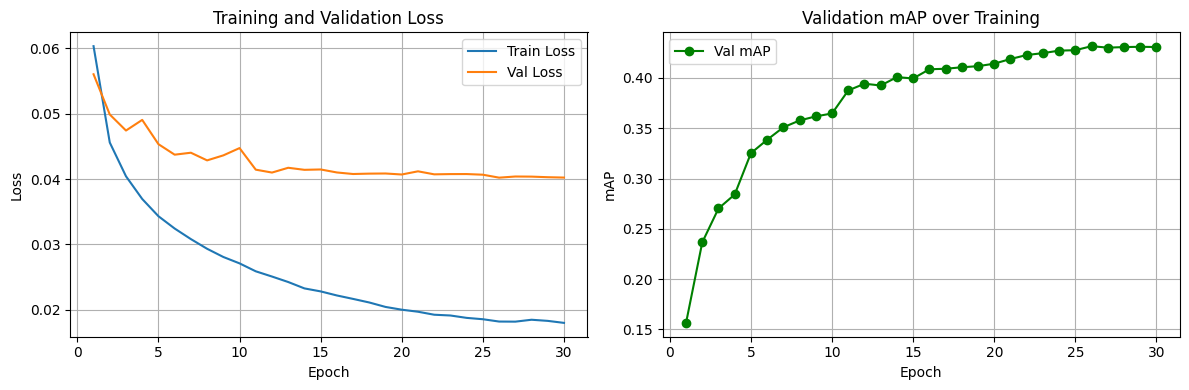

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Figure 1: Loss curves
ax1.plot(epochs_ran, history['train_loss'], label='Train Loss')
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Figure 2: mAP curve — unpack tuples
if history['map']:
    map_epochs, map_values = zip(*history['map'])
    ax2.plot(map_epochs, map_values, label='Val mAP', color='green', marker='o')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('mAP')
    ax2.set_title('Validation mAP over Training')
    ax2.legend()
    ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [ ]:
# load my best model and evaluate final metrics on the validation set
path = 'best_oversampled_model.pt'
model.load_state_dict(torch.load(path))
# predict on validation set and compute metrics
val_dataset = FSD50KDataset(df_val, label_to_idx, num_classes, split='val')
val_loader  = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
all_preds, all_labels, all_probs = evaluate_metrics(val_loader)
print(f"Final validation on best model from {path}:")
_ = compute_all_metrics(all_labels, all_probs)

Final validation on best model from best_oversampled_model.pt:
F1 Micro (tuned): 0.5851  |  F1 Macro (tuned): 0.4681
mAP:    0.432  (paper CRNN: 0.417, VGG-like: 0.434)
d':     2.319         (paper CRNN: 2.068, VGG-like: 2.167)
lωlrap: 0.675  (paper CRNN: 0.519, VGG-like: 0.514)
mAP (6 families): 0.7176


In [ ]:
# Run evaluation
path = 'best_oversampled_specaugmented_model.pt'
model.load_state_dict(torch.load(path))
# predict on validation set and compute metrics
val_dataset = FSD50KDataset(df_val, label_to_idx, num_classes, split='val')
val_loader  = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
all_preds, all_labels, all_probs = evaluate_metrics(val_loader)
print(f"Final validation on best model from {path}:")
_ = compute_all_metrics(all_labels, all_probs)

F1 Micro (tuned): 0.5851  |  F1 Macro (tuned): 0.4681
mAP:    0.432  (paper CRNN: 0.417, VGG-like: 0.434)
d':     2.319         (paper CRNN: 2.068, VGG-like: 2.167)
lωlrap: 0.675  (paper CRNN: 0.519, VGG-like: 0.514)
mAP (6 families): 0.7176
